<a href="https://colab.research.google.com/github/eerga/MLZoomcampHW/blob/main/HW9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 9

## Question 1
To be able to use this model, we need to know the name of the input and output nodes.

What's the name of the output:

- output
- sigmoid
- softmax
- prediction

In [2]:
import requests
PREFIX = "https://github.com/alexeygrigorev/large-datasets/releases/download/hairstyle"
DATA_URL = f"{PREFIX}/hair_classifier_v1.onnx.data"
MODEL_URL = f"{PREFIX}/hair_classifier_v1.onnx"

def download_file(url, filename):
    print(f"📥 Downloading {filename}...")
    response = requests.get(url)
    response.raise_for_status()

    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"✅ Downloaded {filename} ({len(response.content):,} bytes)")

# Download both files
download_file(DATA_URL, "hair_classifier_v1.onnx.data")
download_file(MODEL_URL, "hair_classifier_v1.onnx")

print("🎉 All files downloaded successfully!")


📥 Downloading hair_classifier_v1.onnx.data...
✅ Downloaded hair_classifier_v1.onnx.data (80,355,328 bytes)
📥 Downloading hair_classifier_v1.onnx...
✅ Downloaded hair_classifier_v1.onnx (10,337 bytes)
🎉 All files downloaded successfully!


In [5]:
#!pip install onnx

In [17]:
# Install onnxruntime
#!pip install onnxruntime

In [6]:
import onnx

# Load the ONNX model
model = onnx.load("hair_classifier_v1.onnx")

# Get input names
input_names = [input.name for input in model.graph.input]
print("🔍 Input names:")
for name in input_names:
    print(f"  - {name}")

# Get output names
output_names = [output.name for output in model.graph.output]
print("\n🎯 Output names:")
for name in output_names:
    print(f"  - {name}")

🔍 Input names:
  - input

🎯 Output names:
  - output


Looks like it's output

In [7]:
import torch
from PIL import Image
import numpy as np
import torchvision.models as models
from torchvision import transforms
import os
from torch.utils.data import Dataset
import torch.nn as nn

In [8]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
from io import BytesIO
from urllib import request

from PIL import Image

def download_image(url):
    with request.urlopen(url) as resp:
        buffer = resp.read()
    stream = BytesIO(buffer)
    img = Image.open(stream)
    return img


def prepare_image(img, target_size):
    """Prepare image for model input"""
    if img.mode != 'RGB':
        img = img.convert('RGB')

    img = img.resize(target_size, Image.NEAREST)
    return img

In [15]:
#!pip install pillow

## Question 2: Target size
Let's download and resize this image:

https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg

Based on the previous homework, what should be the target size for the image?

- 64x64
- 128x128
- 200x200
- 256x256

In [ ]:
image = download_image(url = "https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg")

In [12]:
#based on the previous homework, the input size is (200, 200)
target_image = prepare_image(img = image, target_size = (200,200))

In [18]:
#Just for sanity check, let's test
import onnxruntime as ort
import requests
from PIL import Image
import io

# First, let's check what input size the model expects
session = ort.InferenceSession("hair_classifier_v1.onnx")

# Get input shape
input_meta = session.get_inputs()[0]
print(f"🔍 Model input name: {input_meta.name}")
print(f"📐 Model input shape: {input_meta.shape}")

# Extract height and width from input shape [batch, channels, height, width]
if len(input_meta.shape) == 4:
    batch_size, channels, height, width = input_meta.shape
    print(f"📊 Expected image size: {height}x{width}")

🔍 Model input name: input
📐 Model input shape: ['s77', 3, 200, 200]
📊 Expected image size: 200x200


## Question 3
Now we need to turn the image into numpy array and pre-process it.

>Tip: Check the previous homework. What was the pre-processing we did there?

After the pre-processing, what's the value in the first pixel, the R channel?

- -10.73
- -1.073
- 1.073
- 10.73

In [21]:
X = np.array(image.resize((200, 200)))

In [20]:
import torchvision.models as models
from torchvision import transforms

In [ ]:
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.eval();

In [23]:
import numpy as np

# Preprocessing following the previous homework transformations
# transforms.Resize((200, 200)), transforms.ToTensor(), transforms.Normalize(...)

# Step 1: Resize to 200x200 (like transforms.Resize((200, 200)))
img_resized = image.resize((200, 200), Image.LANCZOS)

# Step 2: Convert to numpy array and scale to [0,1] (like transforms.ToTensor())
img_array = np.array(img_resized, dtype=np.float32) / 255.0

# Step 3: Convert from HWC to CHW format (transforms.ToTensor() does this)
img_array = np.transpose(img_array, (2, 0, 1))

# Step 4: Apply ImageNet normalization (like transforms.Normalize)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Apply: (pixel - mean) / std for each channel
for c in range(3):  # R, G, B channels
    img_array[c] = (img_array[c] - mean[c]) / std[c]

print(f"📐 Final array shape: {img_array.shape}")
print(f"🔴 First pixel, R channel value: {img_array[0, 0, 0]}")

# Display the preprocessed image info
print(f"📊 Array dtype: {img_array.dtype}")
print(f"📈 Min value: {img_array.min():.3f}")
print(f"📈 Max value: {img_array.max():.3f}")

📐 Final array shape: (3, 200, 200)
🔴 First pixel, R channel value: -1.0561691522598267
📊 Array dtype: float32
📈 Min value: -2.118
📈 Max value: 2.640


-1.073 is the answer

## Question 4
Now let's apply this model to this image. What's the output of the model?

- 0.09
- 0.49
- 0.69
- 0.89

In [26]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort


# Preprocessing (same as previous homework)
print("🔄 Applying preprocessing...")

# Step 1: Resize to 200x200
img_resized = image.resize((200, 200), Image.LANCZOS)

# Step 2: Convert to array and scale to [0,1] (like transforms.ToTensor())
img_array = np.array(img_resized, dtype=np.float32) / 255.0

# Step 3: Convert from HWC to CHW format
img_array = np.transpose(img_array, (2, 0, 1))

# Step 4: Apply ImageNet normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for c in range(3):  # R, G, B channels
    img_array[c] = (img_array[c] - mean[c]) / std[c]

# Step 5: Add batch dimension
img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 3, 200, 200)

print(f"📐 Final array shape: {img_array.shape}")
print(f"🔴 First pixel, R channel: {img_array[0, 0, 0, 0]}")

# Apply ONNX model
print("\n🚀 Running inference...")

# Load ONNX model
session = ort.InferenceSession("hair_classifier_v1.onnx")
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

# Run inference
result = session.run([output_name], {input_name: img_array})
output = result[0]

print(f"📊 Model output shape: {output.shape}")
print(f"🎯 Model output value: {output[0][0]:.4f}")
print(f"🎯 Rounded output: {output[0][0]:.2f}")

# Check which answer it matches
answers = [0.09, 0.49, 0.69, 0.89]
closest = min(answers, key=lambda x: abs(x - output[0][0]))
print(f"✅ Closest answer: {closest}")

🔄 Applying preprocessing...
📐 Final array shape: (1, 3, 200, 200)
🔴 First pixel, R channel: -1.0561691522598267

🚀 Running inference...
📊 Model output shape: (1, 1)
🎯 Model output value: 0.4146
🎯 Rounded output: 0.41
✅ Closest answer: 0.49


## Question 5
Download the base image agrigorev/model-2025-hairstyle:v1. You can do it with docker pull.

So what's the size of this base image?

- 88 Mb
- 208 Mb
- 608 Mb
- 1208 Mb
<br>You can get this information when running docker images - it'll be in the "SIZE" column.

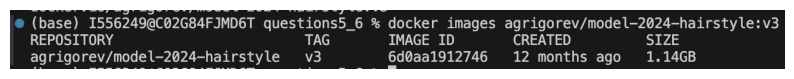

In [27]:
from PIL import Image
import matplotlib.pyplot as plt

img2 = Image.open('docker_size.png')
plt.figure(figsize=(10, 8))
plt.imshow(img2)
plt.axis('off')
plt.show()

Size is 1.14 GB